# Fig: 4-panel containment perimeters (2×2)

Independently computes each containment perimeter from source data, validates
against `config.yaml`, and produces the 4-panel figure:

- **A**: Panhandle core (14 dairy counties)
- **B**: Network-based 99% conditional (1-link + 2-link, 102 counties)
- **C**: Geographic rings via Rook BFS (ring 2 + ring 4, 111 counties)
- **D**: TX + 6 border states (437 dairy counties)

In [1]:
import geopandas as gpd
import yaml, json
from pathlib import Path
from matplotlib.patches import Patch
from collections import deque

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.family': 'sans-serif',
    'axes.labelsize': 10, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

PROJ_ROOT = Path('../..').resolve()
FINAL_DIR = PROJ_ROOT / 'paper' / 'final'
PAPER_DIR = PROJ_ROOT / 'paper'
FIG_DIR = FINAL_DIR / 'figures'
CONFIG_PATH = PROJ_ROOT / 'analysis' / 'simulations' / 'config.yaml'
NETWORK_JSON = PROJ_ROOT / 'analysis' / 'simulations' / 'computed_network_perimeters.json'
RAW_DIR = PROJ_ROOT / 'analysis' / 'H5N1-Simulations-and-Analysis' / 'data' / 'raw'

# ── Load shapefile + FIPS lookup ──
gdf = gpd.read_file(RAW_DIR / 'gadm41_USA_shp' / 'gadm41_USA_2.shp')
fips_lookup = pd.read_csv(RAW_DIR / 'US_FIPS_Codes_formatted.csv')

def norm(s):
    s = str(s).strip().lower()
    s = s.replace('saint ', 'st ').replace('sainte ', 'ste ').replace('st. ', 'st ')
    s = s.replace('de kalb', 'dekalb').replace('du page', 'dupage')
    s = s.replace('mc lean', 'mclean').replace('de witt', 'dewitt')
    s = s.replace('de soto', 'desoto').replace('de baca', 'debaca')
    return s

gdf['join_key'] = gdf['NAME_1'].apply(norm) + '|' + gdf['NAME_2'].apply(norm)
fips_lookup['join_key'] = fips_lookup['state'].apply(norm) + '|' + fips_lookup['county'].apply(norm)
gdf = gdf.merge(fips_lookup[['join_key', 'fips']], on='join_key', how='left')

exclude_states = ['Alaska', 'Hawaii', 'Guam', 'American Samoa',
                  'Northern Mariana Islands', 'Puerto Rico', 'U.S. Virgin Islands']
gdf = gdf[~gdf['NAME_1'].isin(exclude_states)].copy()
gdf['fips_int'] = gdf['fips'].astype('Int64')
gdf['state_fips'] = (gdf['fips_int'] // 1000).astype('Int64')
gdf = gdf.reset_index(drop=True)

# Dairy counties
scenario_csv = PAPER_DIR / 'figures' / 'all_county_origins' / 'scenario_summary.csv'
dairy_fips = set(pd.read_csv(scenario_csv)['seed_county'].unique())
gdf['is_dairy'] = gdf['fips_int'].isin(dairy_fips)

state_boundaries = gdf.dissolve(by='NAME_1').boundary

# FIPS <-> positional index mapping
fips_to_idx = {}
idx_to_fips = {}
for pos in range(len(gdf)):
    f = gdf.at[pos, 'fips_int']
    if pd.notna(f):
        fips_to_idx[int(f)] = pos
        idx_to_fips[pos] = int(f)

print(f'Counties: {len(gdf)}, dairy: {gdf["is_dairy"].sum()}')
print(f'Unmatched FIPS: {gdf["fips"].isna().sum()}')

Counties: 3117, dairy: 2504
Unmatched FIPS: 42


In [2]:
##### APPROACH 1: Panhandle core #####
# The 14 TX Panhandle dairy counties are the seed set for
# all other perimeters. These are defined by geography
# (the 26 counties of the TX Panhandle) filtered to those
# with dairy operations.

panhandle = {
    48065,   # Carson
    48069,   # Castro
    48111,   # Dallam
    48117,   # Deaf Smith
    48129,   # Donley
    48179,   # Gray
    48191,   # Hall
    48205,   # Hartley
    48295,   # Lipscomb
    48341,   # Moore
    48369,   # Parmer
    48421,   # Sherman
    48437,   # Swisher
    48483,   # Wheeler
}

assert all(f in dairy_fips for f in panhandle), 'Not all panhandle FIPS are dairy counties'
print(f'Panhandle: {len(panhandle)} dairy counties')

Panhandle: 14 dairy counties


In [3]:
##### APPROACH 2: Geographic rings (Rook contiguity BFS) #####
# BFS outward from the panhandle through ALL US counties
# (dairy and non-dairy), using Rook contiguity (shared
# edges only; corner-point contacts excluded). Dairy
# counties are collected at each ring depth.
#
# Rook vs Queen: touches() catches both edge and corner
# contacts. We filter to edge contacts by checking that
# the intersection geometry is a line (dimension > 0),
# not a point.

print('Building Rook adjacency (shared edges only)...')
sindex = gdf.sindex
neighbors = {i: set() for i in range(len(gdf))}

for i in range(len(gdf)):
    geom_i = gdf.geometry.iloc[i]
    candidates = list(sindex.intersection(geom_i.bounds))
    for j in candidates:
        if j > i:
            geom_j = gdf.geometry.iloc[j]
            if geom_i.touches(geom_j) or geom_i.intersects(geom_j):
                if geom_i.within(geom_j) or geom_j.within(geom_i):
                    continue
                isect = geom_i.intersection(geom_j)
                # Rook: keep only edge contacts (LineString, MultiLineString)
                # Exclude point contacts (Point, MultiPoint)
                if isect.geom_type in ('LineString', 'MultiLineString',
                                       'GeometryCollection'):
                    # For GeometryCollection, check if it contains any lines
                    if isect.geom_type == 'GeometryCollection':
                        has_line = any(g.geom_type in ('LineString', 'MultiLineString')
                                       for g in isect.geoms)
                        if not has_line:
                            continue
                    neighbors[i].add(j)
                    neighbors[j].add(i)

avg_nb = np.mean([len(v) for v in neighbors.values()])
print(f'Rook adjacency: {len(neighbors)} counties, avg {avg_nb:.1f} neighbors')

# BFS from panhandle
seed_indices = {fips_to_idx[f] for f in panhandle if f in fips_to_idx}
visited = {}
queue = deque()
for idx in seed_indices:
    visited[idx] = 0
    queue.append((idx, 0))

while queue:
    node, depth = queue.popleft()
    for nb in neighbors[node]:
        if nb not in visited:
            visited[nb] = depth + 1
            queue.append((nb, depth + 1))

# Collect dairy counties per ring
ring_dairy = {}
for idx, depth in visited.items():
    fips = idx_to_fips.get(idx)
    if fips and fips in dairy_fips:
        ring_dairy.setdefault(depth, set()).add(fips)

geo_ring2 = set()
for d in range(3):
    geo_ring2 |= ring_dairy.get(d, set())

geo_ring4 = set()
for d in range(5):
    geo_ring4 |= ring_dairy.get(d, set())

print(f'\nRing depth distribution (dairy only):')
for d in range(6):
    if d in ring_dairy:
        cum = set()
        for dd in range(d + 1):
            cum |= ring_dairy.get(dd, set())
        print(f'  Depth {d}: +{len(ring_dairy[d])} (cumulative: {len(cum)})')

print(f'\nGeo ring 2: {len(geo_ring2)} dairy counties')
print(f'Geo ring 4: {len(geo_ring4)} dairy counties')

Building Rook adjacency (shared edges only)...
Rook adjacency: 3117 counties, avg 5.6 neighbors

Ring depth distribution (dairy only):
  Depth 0: +14 (cumulative: 14)
  Depth 1: +14 (cumulative: 28)
  Depth 2: +19 (cumulative: 47)
  Depth 3: +27 (cumulative: 74)
  Depth 4: +37 (cumulative: 111)
  Depth 5: +42 (cumulative: 153)

Geo ring 2: 47 dairy counties
Geo ring 4: 111 dairy counties


In [4]:
##### APPROACH 3: Network-based perimeters (from USAMMv3) #####
# Computed in network_perimeter_analysis.ipynb from 1,000
# USAMMv3 network realizations. Loaded from the output JSON.
#
# net99_1hop: counties receiving direct shipments from
#   panhandle in ≥99% of networks
# net99_2hop_cond: counties reachable via conditional
#   2-hop chains with ≥99% probability

with open(NETWORK_JSON) as f:
    net_data = json.load(f)

net99_1hop = set(net_data['net99_1hop'])
net99_2hop_cond = set(net_data['net99_2hop_conditional'])

print(f'Net99 1-hop: {len(net99_1hop)} dairy counties')
print(f'Net99 2-hop conditional: {len(net99_2hop_cond)} dairy counties')
print(f'  1-hop only: {len(net99_1hop - panhandle)} beyond panhandle')
print(f'  2-hop only: {len(net99_2hop_cond - net99_1hop)} beyond 1-hop')

# Nesting check
assert panhandle <= net99_1hop, 'Panhandle not nested in 1-hop'
assert net99_1hop <= net99_2hop_cond, '1-hop not nested in 2-hop'
print('Nesting: panhandle ⊂ 1-hop ⊂ 2-hop ✓')

Net99 1-hop: 41 dairy counties
Net99 2-hop conditional: 102 dairy counties
  1-hop only: 27 beyond panhandle
  2-hop only: 61 beyond 1-hop
Nesting: panhandle ⊂ 1-hop ⊂ 2-hop ✓


In [5]:
##### APPROACH 4: TX + 6 border states #####
# All dairy counties in TX, NM, OK, AR, LA, KS, CO.
# Defined by state FIPS prefixes.

TX_REGION7_PREFIXES = {48, 35, 40, 5, 22, 20, 8}

tx_region7_dairy = set()
for pos in range(len(gdf)):
    row = gdf.iloc[pos]
    if row['is_dairy'] and pd.notna(row['state_fips']) and int(row['state_fips']) in TX_REGION7_PREFIXES:
        tx_region7_dairy.add(int(row['fips_int']))

n_states = len({f // 1000 for f in tx_region7_dairy})
print(f'TX + 6 border states: {len(tx_region7_dairy)} dairy counties across {n_states} states')

TX + 6 border states: 437 dairy counties across 7 states


In [6]:
##### VALIDATION against config.yaml #####
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)
cs = cfg['county_sets']

checks = [
    ('panhandle',        panhandle,        set(cs['panhandle'])),
    ('geo_ring2',        geo_ring2,         set(cs['geo_ring2'])),
    ('geo_ring4',        geo_ring4,         set(cs['geo_ring4'])),
    ('net99_1hop',       net99_1hop,        set(cs['net99_1hop'])),
    ('net99_2hop_cond',  net99_2hop_cond,   set(cs['net99_2hop_cond'])),
]

all_pass = True
for name, computed, config_set in checks:
    match = computed == config_set
    status = 'PASS' if match else 'FAIL'
    print(f'  {name}: computed={len(computed)}, config={len(config_set)} — {status}')
    if not match:
        all_pass = False
        extra = computed - config_set
        missing = config_set - computed
        if extra:
            print(f'    In computed but not config: {sorted(extra)}')
        if missing:
            print(f'    In config but not computed: {sorted(missing)}')

# TX region has no config county_set — validate via state prefix logic
print(f'  tx_region7: computed={len(tx_region7_dairy)} (no config county_set; validated by state prefixes)')

if all_pass:
    print('\nAll computed sets match config. ✓')
else:
    print('\n⚠ MISMATCH detected — review discrepancies above.')

  panhandle: computed=14, config=14 — PASS
  geo_ring2: computed=47, config=47 — PASS
  geo_ring4: computed=111, config=111 — PASS
  net99_1hop: computed=41, config=41 — PASS
  net99_2hop_cond: computed=102, config=102 — PASS
  tx_region7: computed=437 (no config county_set; validated by state prefixes)

All computed sets match config. ✓


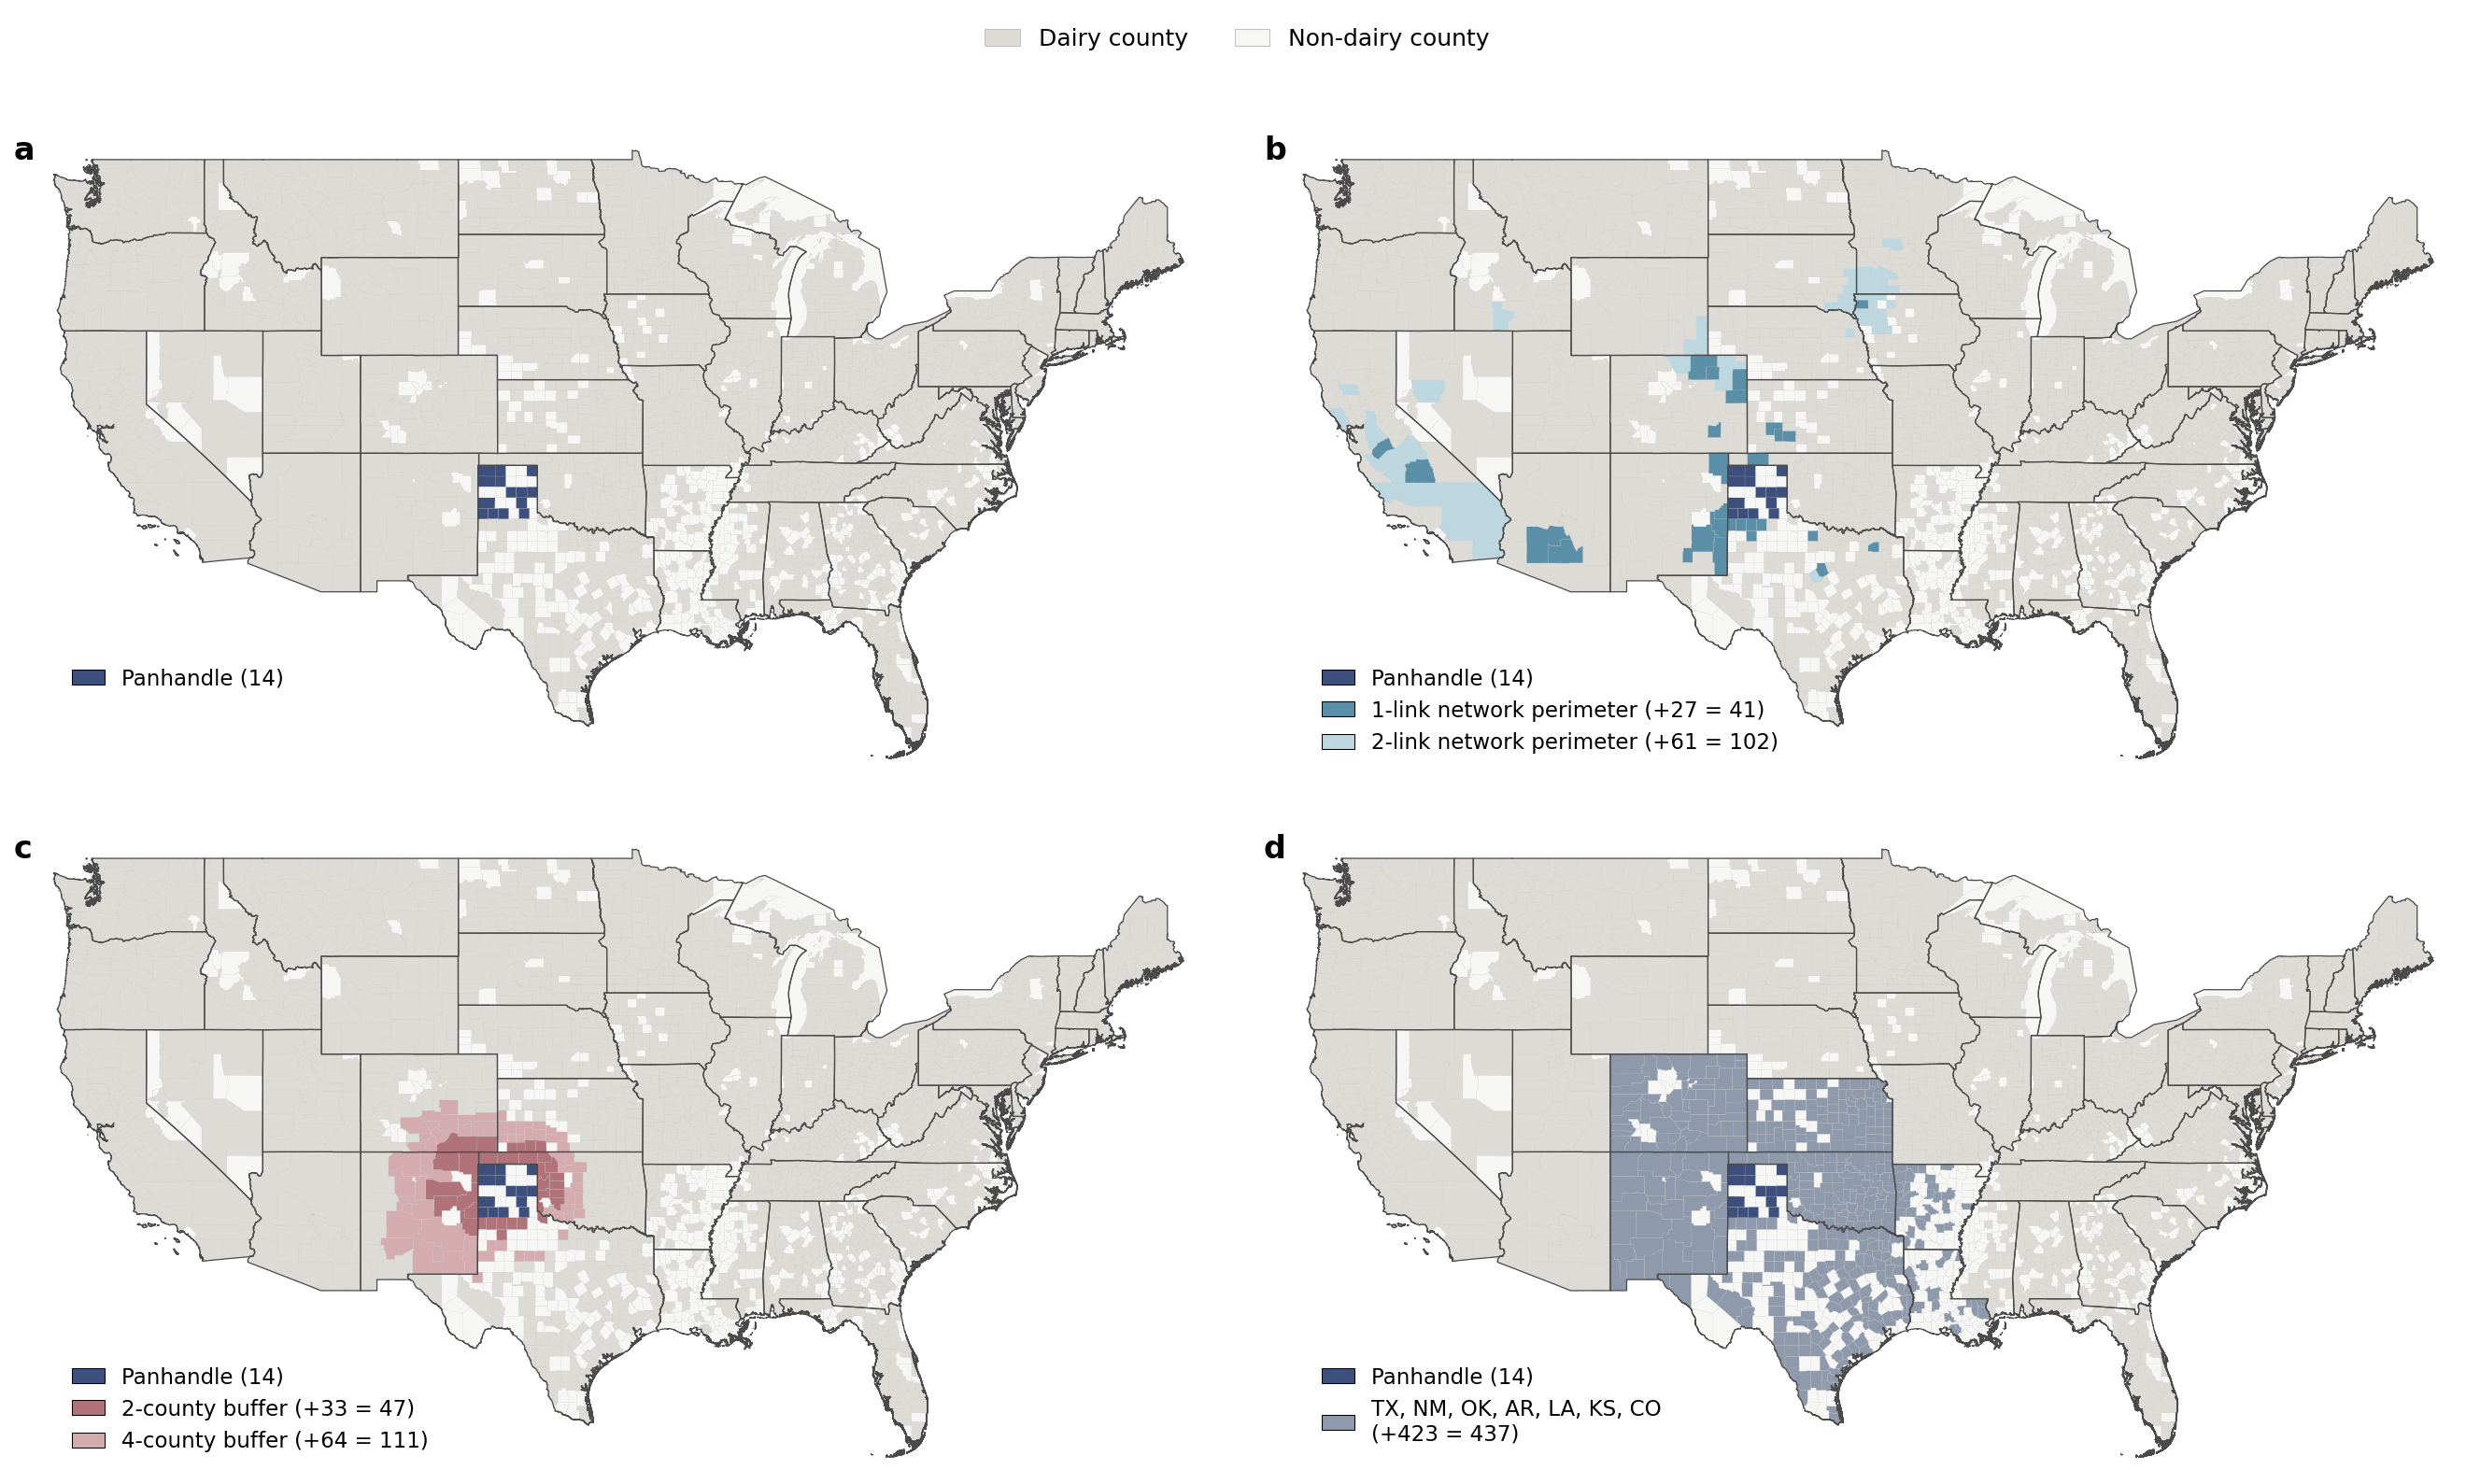

In [8]:
##### 4-PANEL FIGURE (2×2) #####
C_NON_DAIRY = '#F6F6F4'
C_DAIRY     = '#DDDBD6'
C_PANHANDLE = '#3D4F7C'
C_NET_INNER = '#5B8FA8'
C_NET_OUTER = '#BDD7E0'
C_GEO_INNER = '#B0737A'
C_GEO_OUTER = '#D4ACB0'
C_TX_REGION = '#8E9AAB'
C_BORDER    = '#C0C0C0'
C_STATE     = '#4A4A4A'

def assign_colors(gdf, fips_col, color_map, default_dairy, default_non_dairy):
    colors = []
    for _, row in gdf.iterrows():
        fips = row[fips_col]
        assigned = False
        if pd.notna(fips):
            fips = int(fips)
            for fips_set, color in color_map:
                if fips in fips_set:
                    colors.append(color)
                    assigned = True
                    break
        if not assigned:
            colors.append(default_dairy if row['is_dairy'] else default_non_dairy)
    return colors

# Exclusive layers for coloring
geo_ring2_only = geo_ring2 - panhandle
geo_ring4_only = geo_ring4 - geo_ring2
net99_1hop_only = net99_1hop - panhandle
net99_2hop_only = net99_2hop_cond - net99_1hop
tx_region7_outer = tx_region7_dairy - panhandle

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

LEGEND_TOP = 0.2
LEGEND_LEFT = 0

panel_configs = [
    {
        'ax': axes[0, 0],
        'label': 'a',
        'color_map': [(panhandle, C_PANHANDLE)],
        'legend_items': [
            Patch(facecolor=C_PANHANDLE, edgecolor='k', lw=0.5, label=f'Panhandle ({len(panhandle)})'),
        ],
    },
    {
        'ax': axes[0, 1],
        'label': 'b',
        'color_map': [(panhandle, C_PANHANDLE), (net99_1hop_only, C_NET_INNER), (net99_2hop_only, C_NET_OUTER)],
        'legend_items': [
            Patch(facecolor=C_PANHANDLE, edgecolor='k', lw=0.5, label=f'Panhandle ({len(panhandle)})'),
            Patch(facecolor=C_NET_INNER, edgecolor='k', lw=0.5, label=f'1-link network perimeter (+{len(net99_1hop_only)} = {len(net99_1hop)})'),
            Patch(facecolor=C_NET_OUTER, edgecolor='k', lw=0.5, label=f'2-link network perimeter (+{len(net99_2hop_only)} = {len(net99_2hop_cond)})'),
        ],
    },
    {
        'ax': axes[1, 0],
        'label': 'c',
        'color_map': [(panhandle, C_PANHANDLE), (geo_ring2_only, C_GEO_INNER), (geo_ring4_only, C_GEO_OUTER)],
        'legend_items': [
            Patch(facecolor=C_PANHANDLE, edgecolor='k', lw=0.5, label=f'Panhandle ({len(panhandle)})'),
            Patch(facecolor=C_GEO_INNER, edgecolor='k', lw=0.5, label=f'2-county buffer (+{len(geo_ring2_only)} = {len(geo_ring2)})'),
            Patch(facecolor=C_GEO_OUTER, edgecolor='k', lw=0.5, label=f'4-county buffer (+{len(geo_ring4_only)} = {len(geo_ring4)})'),
        ],
    },
    {
        'ax': axes[1, 1],
        'label': 'd',
        'color_map': [(panhandle, C_PANHANDLE), (tx_region7_outer, C_TX_REGION)],
        'legend_items': [
            Patch(facecolor=C_PANHANDLE, edgecolor='k', lw=0.5, label=f'Panhandle ({len(panhandle)})'),
            Patch(facecolor=C_TX_REGION, edgecolor='k', lw=0.5, label=f'TX, NM, OK, AR, LA, KS, CO\n(+{len(tx_region7_outer)} = {len(tx_region7_dairy)})'),
        ],
    },
]

for pcfg in panel_configs:
    ax = pcfg['ax']
    colors = assign_colors(gdf, 'fips_int', pcfg['color_map'], C_DAIRY, C_NON_DAIRY)
    gdf.plot(ax=ax, color=colors, edgecolor=C_BORDER, linewidth=0.08)
    state_boundaries.plot(ax=ax, color=C_STATE, linewidth=0.6, zorder=4)
    ax.set_xlim(-125, -66)
    ax.set_ylim(24, 50)
    ax.set_axis_off()
    ax.text(-0.03, 1.0, pcfg['label'], transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left')
    if pcfg['legend_items']:
        ax.legend(handles=pcfg['legend_items'], loc='upper left', fontsize=11,
                  frameon=False, borderpad=0.6, handlelength=1.5,
                  bbox_to_anchor=(LEGEND_LEFT, LEGEND_TOP))

# Shared legend at top of figure
shared_handles = [
    Patch(facecolor=C_DAIRY, edgecolor=C_BORDER, lw=0.5, label='Dairy county'),
    Patch(facecolor=C_NON_DAIRY, edgecolor=C_BORDER, lw=0.5, label='Non-dairy county'),
]
fig.legend(handles=shared_handles, loc='upper center', ncol=2, fontsize=12,
           frameon=False, borderpad=0.6, handlelength=1.5,
           bbox_to_anchor=(0.5, 1.08))

fig.tight_layout(w_pad=1, h_pad=2)

# fig.savefig(FIG_DIR / 'Fig_ContainmentPerimeters_4panel_v2.png', dpi=300, bbox_inches='tight')
# fig.savefig(FIG_DIR / 'Fig_ContainmentPerimeters_4panel_v2.pdf', bbox_inches='tight')

# print('Fig_ContainmentPerimeters_4panel_v2 saved.')
plt.show()